# Practice Problem: Heat Diffusion in 2D

Study thermal diffusion in 2D using the **Crank-Nicolson method**. Consider the diffusion of a quantity $u(x, y, t)$ over a two-dimensional spatial domain $ x\in = [-L_x,+L_x]$ and $y\in [-L_y,+L_y]$.

The governing equation for this process is the 2D diffusion equation:

$$
\frac{\partial u}{\partial t} = c \left( \frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} \right)
$$

where $c$ is the diffusion coefficient.

At time $t=0$, the quantity $u(x, y, 0)$ is a **square pulse** centered at the origin $(0,0)$ equal to $1.0$ within the region $[-\frac{L_x}{6}, +\frac{L_x}{6}] \times [-\frac{L_y}{6}, +\frac{L_y}{6}] $ and $0.0$ everywhere else. Implement fixed **Dirichlet** boundary conditions where the value of $u$ is held at $0.0$ along all four edges of the domain for all times.



## 2D Heat Diffusion Equation

We need to solve the 2D diffusion (heat) equation:

$$\frac{\partial u}{\partial t}=c \left(\frac{\partial^2 u}{\partial x^2}+\frac{\partial^2 u}{\partial y^2}\right)$$

where:

- $u(x,y,t)$ is the temperature (or scalar field),
  
- $c$ is the diffusion coefficient.


## Spatial and Temporal Discretisation

Using a uniform Cartesian grid:

$$
x_i = i \Delta x,
\qquad
y_j = j \Delta y,
\qquad
t^n = n \Delta t
$$

with:

$$u_{i,j}^n \approx u(x_i,y_j,t^n)$$


## Crank-Nicolson Scheme
Recall that the CN method is:

- second-order accurate in time,

- second-order accurate in space,

- unconditionally stable for diffusion problems,

- implicit (requires solving a linear system each timestep).

The discretised equation is:

$$\frac{u_{i,j}^{n+1} - u_{i,j}^{n}}{\Delta t}=\frac{c}{2}\left[\nabla^2 u^{n+1}+\nabla^2 u^{n}\right]$$

Using the finite-difference Laplacian:

$$\nabla^2 u_{i,j}=\frac{u_{i+1,j}+u_{i-1,j}+u_{i,j+1}+u_{i,j-1}-4u_{i,j}}{\Delta x^2}$$

we obtain:

$$u_{i,j}^{n+1}-\alpha\left(u_{i+1,j}^{n+1}+u_{i-1,j}^{n+1}+u_{i,j+1}^{n+1}+u_{i,j-1}^{n+1}-4u_{i,j}^{n+1}\right)=$$

$$u_{i,j}^{n}+\alpha\left(u_{i+1,j}^{n}+u_{i-1,j}^{n}+u_{i,j+1}^{n}+u_{i,j-1}^{n}-4u_{i,j}^{n}\right)$$

where:

$$\alpha=\frac{c \Delta t}{2 \Delta x^2}$$

## Matrix Form

The scheme can be written as:

$$A \mathbf{u}^{n+1}=B \mathbf{u}^{n}$$

where:

$$\mathbf{u}=\text{flatten}(u_{i,j})$$

is the flattened 2D grid.


### LHS:
The matrix $A$ contains:

- diagonal terms:

$$1 + 4\alpha$$

- nearest-neighbour couplings:

$$-\alpha$$

Thus:

$$A = (I + 4\alpha I) -\alpha\left(T_x + T_y\right)$$

### RHS:

Similarly, the RHS matrix $B$ is:

$$B =(I - 4\alpha I)+\alpha\left(T_x + T_y\right)$$

with coefficients:

$$1 - 4\alpha$$

and neighbor terms:

$$+\alpha$$


## Boundary Conditions

Non-periodic boundaries are enforced by removing couplings between adjacent rows after flattening:

$$A_{iN_x-1,\; iN_x} = 0.$$

$$A_{iN_x,\; iN_x-1} = 0.$$

and similarly for $B$.

This prevents artificial wrapping between the right edge and left edge of the grid.


## Time Evolution:

At every time step we do tthe following:

1. Compute the RHS:

$$\mathbf{b}=B \mathbf{u}^{n}$$

2. Solve the linear system:

$$A \mathbf{u}^{n+1}=\mathbf{b}$$

3. Reshape back into 2D.


In [1]:
# Import libraries

import numpy as np
import matplotlib.pyplot as plt

# VTK formatting
from pyevtk.hl import gridToVTK

## Domain definition:

In [2]:
# Define the domain and resolution
Lx = Ly = 1.0
Nx = Ny = 40

# Spatial steps (index i)
delta_x = delta_y = 2*Lx/Nx

# Diffusion coeficient
c = 1.

# Time step
t_sim = 0.1
n_t   = 100
delta_t = t_sim/n_t

#print(delta_t)

### Mesh creation

In [3]:
# 2D axes
x = np.linspace(-Lx, +Lx, Nx)
y = np.linspace(-Ly, +Ly, Ny)

# Meshgrid
x_2d, y_2d = np.meshgrid(x, y)

#print(x_2d.size)

### Initial condition

In [4]:
# Empty array
u = np.zeros((Nx, Ny))

#print(u.shape)
# Add 1's inside the central box
u[Nx //2 - Nx // 6:Nx//2 + Nx // 6, Ny //2 - Ny // 6:Ny//2 + Ny // 6] = 1.


### Plotting the IC:

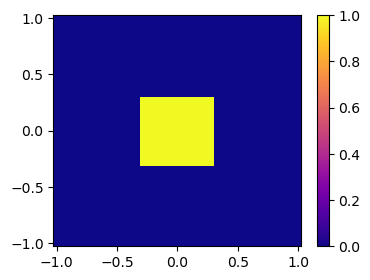

In [5]:
plt.figure(figsize=(4,3))

z_0 = plt.pcolor(x_2d, y_2d, u, cmap = "plasma", clim = (0,1))

plt.colorbar(z_0)

plt.show()

### Numerics:

$\alpha=\frac{c\,\Delta t}{2\,\Delta x^2}$

In [6]:
# Define alpha

alpha = c*delta_t/(2*delta_x**2)

print(-alpha, 1+ 4.*alpha)

-0.19999999999999996 1.7999999999999998


In [7]:
# Flatten the grid
N = Nx*Ny



### LHS of the Crank Nicolson Method:

In [8]:
# Diagonal elements
diag_0 = (1 + 4*alpha)*np.ones(N)
diag_s = -alpha*np.ones(N - 1)
diag_u = -alpha*np.ones(N - Nx)
#print(diag_s.shape)

# For the A matrix (LHS)

a_matrix = np.diag(diag_0)
a_matrix += np.diag(diag_s, k = 1)
a_matrix += np.diag(diag_s, k = -1)
a_matrix += np.diag(diag_u, k = Nx)
a_matrix += np.diag(diag_u, k = -Nx)


In [9]:
#print(a_matrix[4, :])

In [10]:
# Non-periodic boundary conditions
for i in range(1, Ny):
    # Last element of previous row and first element of current row = 0
    a_matrix[i * Nx - 1, i * Nx] = 0
    a_matrix[i * Nx, i * Nx - 1] = 0

In [11]:
print(a_matrix[3, :])

print(a_matrix[4, :])

[ 0.   0.  -0.2 ...  0.   0.   0. ]
[0. 0. 0. ... 0. 0. 0.]


In [12]:
# Define
b = u.flatten()

#print(b.shape)

# Flattened solution
u_new = np.linalg.solve(a_matrix, b)

print(u_new.shape)

# Reshape solution
u_new = u_new.reshape((Nx, Ny))

print(u_new.shape)

(1600,)
(40, 40)


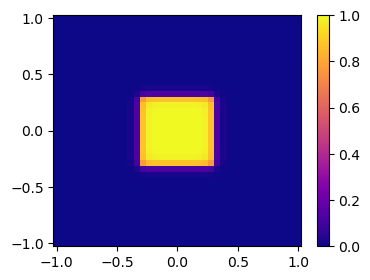

In [13]:
plt.figure(figsize=(4,3))

z_0 = plt.pcolor(x_2d, y_2d, u_new, cmap = "plasma", clim = (0,1))

plt.colorbar(z_0)

plt.show()

### RHS of the Crank-Nicolson method

In [14]:
# Diagonal elements
diag_0 = (1 - 4*alpha)*np.ones(N)
diag_s = alpha*np.ones(N - 1)
diag_u = alpha*np.ones(N - Nx)
#print(diag_s.shape)

# For the A matrix (LHS)

b_matrix = np.diag(diag_0)
b_matrix += np.diag(diag_s, k = 1)
b_matrix += np.diag(diag_s, k = -1)
b_matrix += np.diag(diag_u, k = Nx)
b_matrix += np.diag(diag_u, k = -Nx)

print(b_matrix)

[[0.2 0.2 0.  ... 0.  0.  0. ]
 [0.2 0.2 0.2 ... 0.  0.  0. ]
 [0.  0.2 0.2 ... 0.  0.  0. ]
 ...
 [0.  0.  0.  ... 0.2 0.2 0. ]
 [0.  0.  0.  ... 0.2 0.2 0.2]
 [0.  0.  0.  ... 0.  0.2 0.2]]


In [15]:
for i in range(1, Ny):
    b_matrix[i * Nx - 1, i * Nx] = 0
    b_matrix[i * Nx, i * Nx - 1] = 0

In [16]:
# Define b using the explicit step
b = b_matrix @ u.flatten()

# Flattened solution
u_new = np.linalg.solve(a_matrix, b)

print(u_new.shape)

# Reshape solution
u_new = u_new.reshape((Nx, Ny))

print(u_new.shape)

(1600,)
(40, 40)


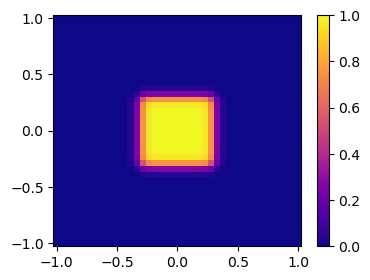

In [17]:
plt.figure(figsize=(4,3))

z_0 = plt.pcolor(x_2d, y_2d, u_new, cmap = "plasma", clim = (0,1))

plt.colorbar(z_0)

plt.show()

### Time evolution loop


In [18]:
# Empty 3D array (t,y,x)

macro_arr = np.zeros((n_t, Ny, Nx))

print(macro_arr.shape)

macro_arr[0, :, : ] = u

(100, 40, 40)


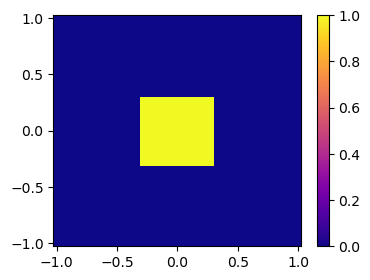

In [19]:
plt.figure(figsize=(4,3))

z_0 = plt.pcolor(x_2d, y_2d, macro_arr[0, :, : ], cmap = "plasma", clim = (0,1))

plt.colorbar(z_0)

plt.show()

In [20]:
# Make a copy of the initial condition
u_new = u.copy()

# For loop in time
for n in range(n_t - 1):
    #print(n)

    # Define b using the explicit step - RHS
    b = b_matrix @ u_new.flatten()
    
    # Flattened solution - LHS
    u_new = np.linalg.solve(a_matrix, b)
    
    #print(u_new.shape)
    
    # Reshape solution
    u_new = u_new.reshape((Nx, Ny))
    
    #print(u_new.shape)

    macro_arr[n + 1, :, :] = u_new.copy()

    

In [21]:
for k in range(n_t):
    
    # 2D projection
    plt.figure(figsize=(4,3))
    z_0 = plt.pcolor(x_2d, y_2d, macro_arr[k, :, : ], cmap = "plasma", clim = (0,1))

    plt.colorbar(z_0, shrink=0.6, pad=0.1)

    plt.xlim(-1., +1.)
    plt.ylim(-1., +1.)

    plt.savefig(f"dif2d{k:03d}.png", bbox_inches='tight', pad_inches=0)
    plt.close()
    
    # 3D representation
    fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(8,7))
    
    z_0 = ax.plot_surface(x_2d, y_2d, macro_arr[k, :, : ], cmap = "plasma", clim = (0,1))

    plt.colorbar(z_0, shrink=0.6, pad=0.1)

    ax.set_xlim(-1., 1.)
    ax.set_ylim(-1., 1.)
    ax.set_zlim(0., 1.1)

    plt.savefig(f"surf{k:03d}.png", bbox_inches='tight')
    plt.close()

    # Export a VTK file
    
    

In [22]:
#!pwd
#!ls -ltr *.png

## Animations:

In [23]:
import os
import glob
from PIL import Image # Pillow library -> PIL
from IPython import display

In [24]:
# Animation:

images_input = "./dif2d***.png"
imgif_output = "./dif2d.gif"

# Collect the images
imgs = (Image.open(f) for f in sorted(glob.glob(images_input)))

img = next(imgs)

img.save(fp = imgif_output, format="GIF", append_images=imgs,\
        save_all=True, duration = 100, loop = 0)

In [25]:
#display.Image(open('./dif2d.gif','rb').read())

In [26]:
# Animation:

images_input = "./surf***.png"
imgif_output = "./surf.gif"

# Collect the images
imgs = (Image.open(f) for f in sorted(glob.glob(images_input)))

img = next(imgs)

img.save(fp = imgif_output, format="GIF", append_images=imgs,\
        save_all=True, duration = 100, loop = 0)

In [27]:
#display.Image(open('surf.gif','rb').read())

In [28]:
print(macro_arr[k, :, : ].shape)

(40, 40)


In [29]:
print(type(x))

<class 'numpy.ndarray'>


In [30]:
t = np.linspace(0, t_sim, n_t)
print(t.shape)

(100,)


In [32]:
gridToVTK("dif3d", t, y, x, pointData={"temp": macro_arr})

'/Users/wbandabarragan/Library/CloudStorage/Dropbox/GitHub_Repos/computational-physics-2/unit-5/dif3d.vtr'

In [38]:
print(x.shape, y.shape, z.shape, macro_arr[k, :, : ].shape)

(40,) (40,) (1,) (40, 40)


In [51]:
for k in range(n_t):

    # Output File
    out_file = f"diffusion_{k}"

    z = np.array([0.])

    reshaped_cell_data = macro_arr[k, :, :].T.reshape(40, 40, 1)
    
    # Export a VTK file
    gridToVTK(out_file, x, y, z, cellData={"temp": reshaped_cell_data.T})
    
    